In [1]:
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from scipy import sparse
from datetime import datetime
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from torch.utils.data import Dataset, DataLoader

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)


## Data Collection
df = pd.read_csv("Product.csv", encoding='latin1')
df.columns = df.columns.str.strip()

df["CustomerID"] = df["CustomerID"].astype('int32')
df["ProductID"] = df["ProductID"].astype('int32')
df["Quantity"] = df["Quantity"].astype('int32')
df["Price"] = df["Price"].astype('int32')

display(df.head(5))
display(df.info())

,CustomerID,ProductID,Product,Category,Quantity,Date,Time,Price
0,10161,702,Handcrafted Italian Leather Formal Shoes,Shoes,5,01-01-2025,13:06:21,60300
1,10189,683,Titanium Automatic GMT Watch,Watches,1,01-01-2025,10:36:49,58400
2,10310,406,Handcrafted Leather Travel Bag,Fashion,5,01-01-2025,09:45:29,30700
3,10389,577,Persian Silk Area Rug,Home Decor,2,01-01-2025,13:31:49,47800
4,10625,401,Walnut Wood Credenza,Furniture,3,01-01-2025,11:19:05,30200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   CustomerID  100000 non-null  int32 
 1   ProductID   100000 non-null  int32 
 2   Product     100000 non-null  object
 3   Category    100000 non-null  object
 4   Quantity    100000 non-null  int32 
 5   Date        100000 non-null  object
 6   Time        100000 non-null  object
 7   Price       100000 non-null  int32 
dtypes: int32(4), object(4)
memory usage: 4.6+ MB


None

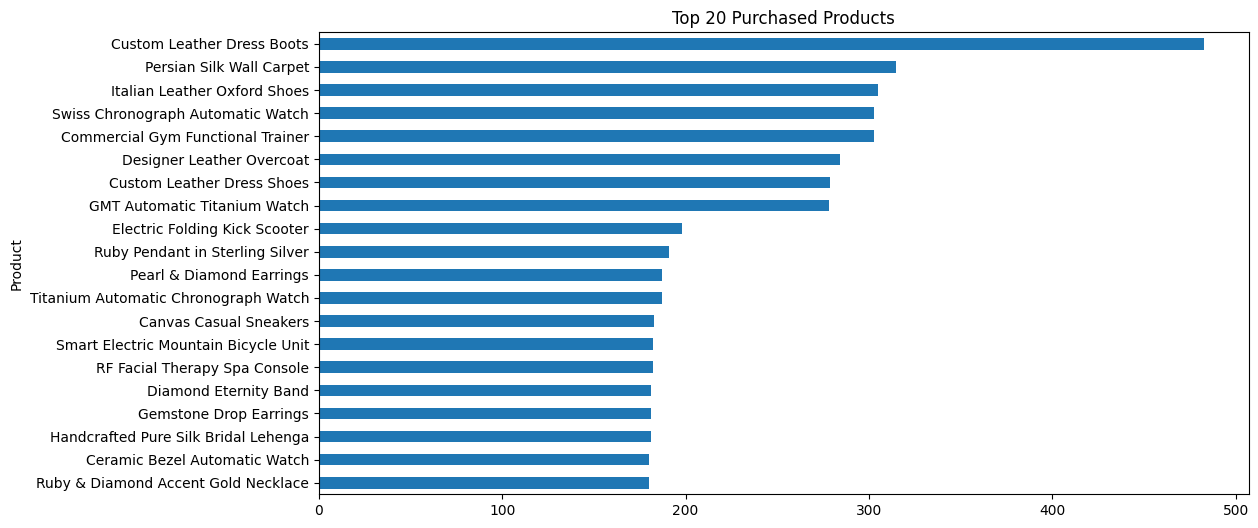

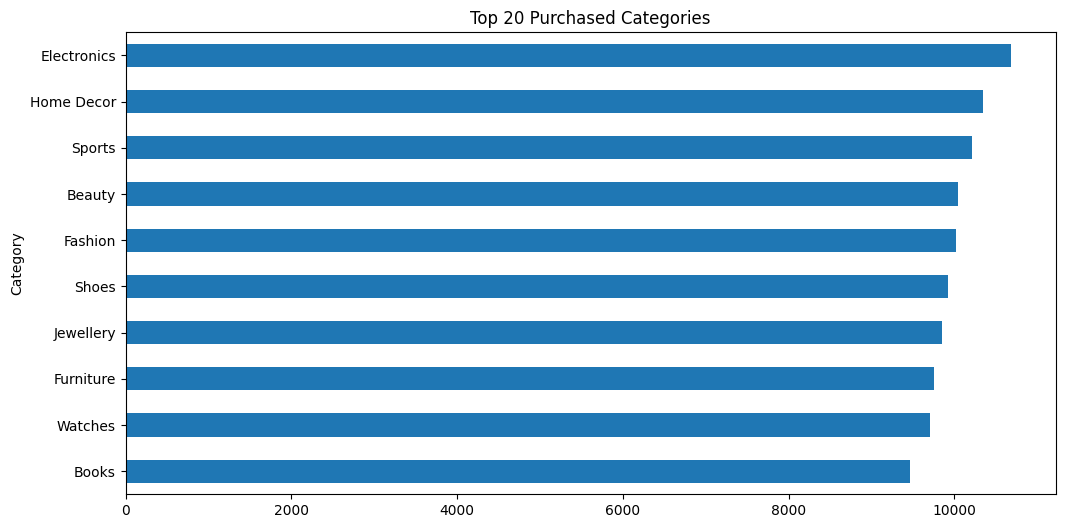

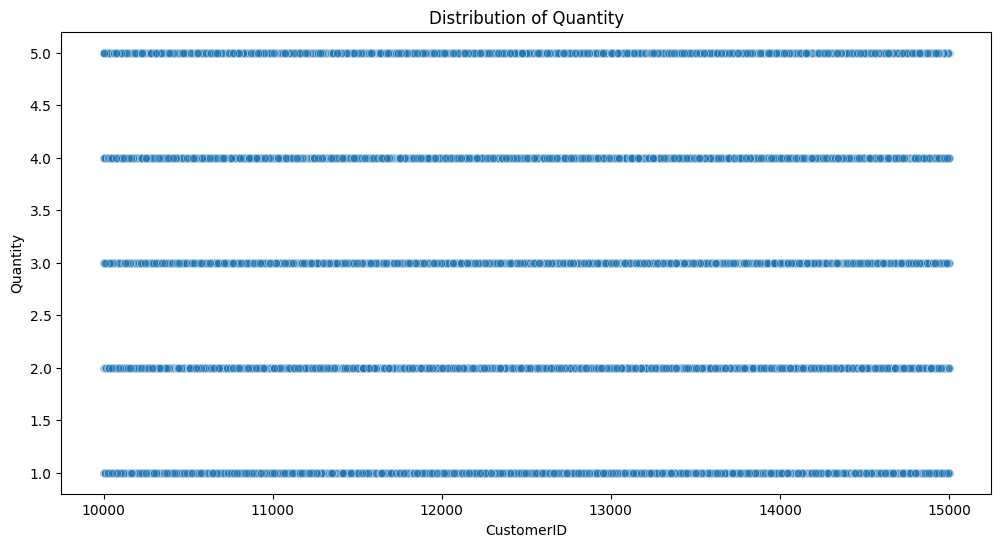

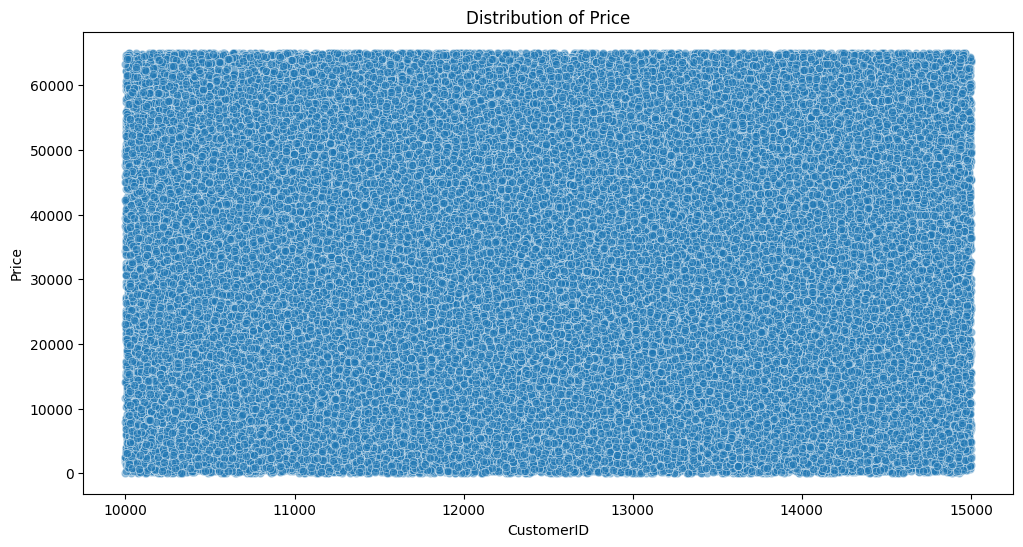

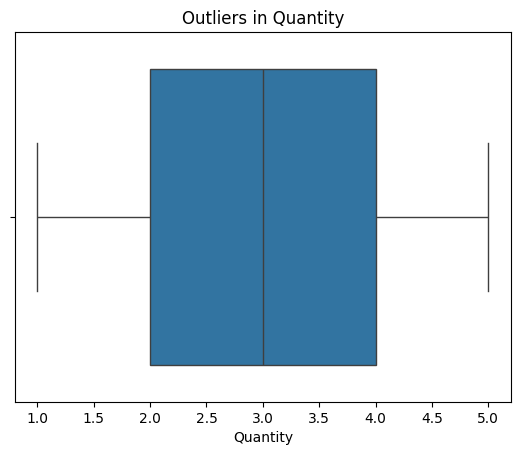

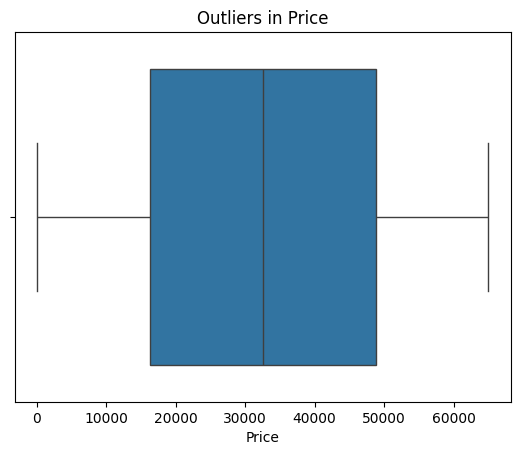

In [2]:
num_cols = ['Quantity', 'Price']

### Top Products
plt.figure(figsize=(12,6))
df['Product'].value_counts().head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 20 Purchased Products')
plt.show()

### Top Categories
plt.figure(figsize=(12,6))
df['Category'].value_counts().head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 20 Purchased Categories')
plt.show()

### Univariate Analysis 
for col in num_cols:
    plt.figure(figsize=(12,6))
    sns.scatterplot(data=df, x="CustomerID", y=col, alpha=0.5)
    plt.title(f'Distribution of {col}')
    plt.show()

### Outlier Detection
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Outliers in {col}')
    plt.show()

In [3]:
n_customers = df.CustomerID.nunique()
n_products = df.ProductID.nunique()
sparsity = (1 - len(df) / (n_customers * n_products))

print("Unique Users :", n_customers)
print("Unique Products :", n_products)
print(f"{sparsity * 100:.2f}% of user-item matrix is empty and only about {100 - (sparsity * 100):.2f}% of all possible user-item interactions are present.")

train_size = int(len(df) * 0.80)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

Unique Users : 5001
Unique Products : 650
96.92% of user-item matrix is empty and only about 3.08% of all possible user-item interactions are present.


In [4]:
### Popularity Recommendation with Categories
train_df_time = train_df.copy()
train_df_time['Hour'] = pd.to_datetime(train_df_time['Time'], format='%H:%M:%S').dt.hour

# Overall popular products per category
category_popular_products = (
    train_df.groupby(["Category", "Product"])["Quantity"]
    .sum()
    .reset_index()
    .sort_values(by=["Category", "Quantity"], ascending=[True, False])
)

# Overall top popular products across all categories
popular_products = (
    train_df.groupby("Product")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .index.tolist()
)

# Hourly popular products grouped by Category
hourly_category_popularity = {}
for hour in range(24):
    hour_data = train_df_time[train_df_time['Hour'] == hour]
    if not hour_data.empty:
        hourly_cat_df = (
            hour_data.groupby(["Category", "Product"])["Quantity"]
            .sum()
            .reset_index()
            .sort_values(by=["Category", "Quantity"], ascending=[True, False])
        )
        hourly_category_popularity[hour] = hourly_cat_df
    else:
        hourly_category_popularity[hour] = category_popular_products


def popular_recommend(target_time=None, category=None, top_n=25):
    """
    Recommends top products based on hour and/or category.
    - If category is provided: returns top products in that category.
    - If category is None: returns top products globally across all categories.
    """
    # 1. Resolve hour
    if target_time is None:
        hour = datetime.now().hour
    elif isinstance(target_time, int):
        hour = target_time
    elif isinstance(target_time, str):
        hour = pd.to_datetime(target_time, format='%H:%M:%S').hour
    elif isinstance(target_time, datetime):
        hour = target_time.hour
    else:
        hour = datetime.now().hour

    # 2. Get hourly data
    hour_df = hourly_category_popularity.get(hour, category_popular_products)

    # 3. Filter by Category if specified
    if category is not None:
        cat_data = hour_df[hour_df['Category'] == category]
        if not cat_data.empty:
            return cat_data['Product'].head(top_n).tolist()
        
        # Fallback to general category popularity if hour has no sales for this category
        gen_cat_data = category_popular_products[category_popular_products['Category'] == category]
        return gen_cat_data['Product'].head(top_n).tolist()

    # 4. Global top products if no category requested
    if isinstance(hour_df, pd.DataFrame):
        return hour_df['Product'].drop_duplicates().head(top_n).tolist()
    
    return popular_products[:top_n]

In [7]:
### User Item Matrix 

user_item = train_df.pivot_table(index="CustomerID", columns="Product", values="Quantity", aggfunc="sum", fill_value=0)

user_similarity = cosine_similarity(user_item)
item_similarity = cosine_similarity(user_item.T)
user_similarity_df = pd.DataFrame(user_similarity, index = user_item.index, columns = user_item.index)
item_similarity_df = pd.DataFrame(item_similarity, index = user_item.columns, columns = user_item.columns)


### User Based Collaborative Recommendation
def user_based_recommend(customer_id, top_n = 25):
    if customer_id not in user_item.index:
        return []

    similar_users = (user_similarity_df[customer_id].sort_values(ascending=False).iloc[1:6].index)
    purchased = (user_item.loc[customer_id])
    purchased = (purchased[purchased > 0].index)

    scores = {}
    for user in similar_users:
        items = user_item.loc[user]
        for product in items[items > 0].index:
            if product not in purchased:
                scores[product] = (scores.get(product, 0) + items[product])

    scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [x[0] for x in scores[:top_n]]


user_similarity_df = user_similarity_df.astype('float32')
user_similarity_df.index = user_similarity_df.index.astype(object)
user_similarity_df.columns = user_similarity_df.columns.astype(object)


### Item Based Collaborative Recommendation
def item_based_recommend(product, top_n = 25):
    if product not in item_similarity_df.index:
        return []

    return (item_similarity_df[product].sort_values(ascending=False).iloc[1:top_n+1].index.tolist())


item_similarity_df = item_similarity_df.astype('float32')
item_similarity_df.index = item_similarity_df.index.astype(object)
item_similarity_df.columns = item_similarity_df.columns.astype(object)

In [8]:
# Neural Collaborative Filtering Recommendation with Category Embeddings
g = torch.Generator()
g.manual_seed(42)

unique_customers = train_df['CustomerID'].unique()
unique_products = df['Product'].unique()
unique_categories = df['Category'].unique()

user2idx = {user: i for i, user in enumerate(unique_customers)}
product2idx = {prod: i for i, prod in enumerate(unique_products)}
cat2idx = {cat: i for i, cat in enumerate(unique_categories)}

idx2user = {i: user for user, i in user2idx.items()}
idx2product = {i: prod for prod, i in product2idx.items()}

# Mapping each product to its category index
prod2cat_map = df.drop_duplicates('Product').set_index('Product')['Category'].map(cat2idx).to_dict()


class RecDataset(Dataset):
    def __init__(self, df, user2idx, product2idx, prod2cat_map):
        valid_rows = df[df['CustomerID'].isin(user2idx) & df['Product'].isin(product2idx)].copy()
        
        self.users = torch.tensor([user2idx[u] for u in valid_rows['CustomerID']], dtype=torch.long)
        self.products = torch.tensor([product2idx[p] for p in valid_rows['Product']], dtype=torch.long)
        self.categories = torch.tensor([prod2cat_map[p] for p in valid_rows['Product']], dtype=torch.long)
        self.labels = torch.ones(len(self.users), dtype=torch.float32)

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return self.users[idx], self.products[idx], self.categories[idx], self.labels[idx]


train_dataset = RecDataset(train_df, user2idx, product2idx, prod2cat_map)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, generator=g)


class NCF(nn.Module):
    def __init__(self, num_users, num_items, num_categories, embedding_dim=32, cat_dim=16):
        super(NCF, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        self.cat_embedding = nn.Embedding(num_categories, cat_dim)

        # Input dimension = User Embedding + Item Embedding + Category Embedding
        self.fc_layers = nn.Sequential(
            nn.Linear(embedding_dim * 2 + cat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, user_indices, item_indices, cat_indices):
        u_emb = self.user_embedding(user_indices)
        i_emb = self.item_embedding(item_indices)
        c_emb = self.cat_embedding(cat_indices)
        
        x = torch.cat([u_emb, i_emb, c_emb], dim=-1)
        return self.fc_layers(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ncf_model = NCF(
    num_users=len(user2idx), 
    num_items=len(product2idx), 
    num_categories=len(cat2idx), 
    embedding_dim=32, 
    cat_dim=16
).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(ncf_model.parameters(), lr=0.001)

ncf_model.train()
epochs = 5
for epoch in range(epochs):
    total_loss = 0
    for users, items, cats, labels in train_loader:
        users, items, cats, labels = users.to(device), items.to(device), cats.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = ncf_model(users, items, cats).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    print(f"Epoch {epoch + 1}/{epochs} - Loss: {total_loss / len(train_loader):.4f}")


def ncf_recommend(customer_id, top_n=25):
    if customer_id not in user2idx:
        return []

    user_idx = user2idx[customer_id]
    purchased = set(user_item.loc[customer_id][user_item.loc[customer_id] > 0].index) if customer_id in user_item.index else set()

    candidate_products = [p for p in unique_products if p not in purchased]
    candidate_indices = [product2idx[p] for p in candidate_products]
    candidate_cat_indices = [prod2cat_map[p] for p in candidate_products]

    u_tensor = torch.tensor([user_idx] * len(candidate_indices), dtype=torch.long).to(device)
    i_tensor = torch.tensor(candidate_indices, dtype=torch.long).to(device)
    c_tensor = torch.tensor(candidate_cat_indices, dtype=torch.long).to(device)

    ncf_model.eval()
    with torch.no_grad():
        scores = ncf_model(u_tensor, i_tensor, c_tensor).squeeze().cpu().numpy()
        top_indices = scores.argsort()[::-1][:top_n]

    return [candidate_products[i] for i in top_indices]

Epoch 1/5 - Loss: 0.0501
Epoch 2/5 - Loss: 0.0002
Epoch 3/5 - Loss: 0.0001
Epoch 4/5 - Loss: 0.0000
Epoch 5/5 - Loss: 0.0000


In [9]:
### Content Based Recommendation
product_data = (
    train_df[['Product', 'Category']]
    .drop_duplicates(subset=['Product'])
    .reset_index(drop=True)
)
product_data['content_text'] = (
    product_data['Category'] + " " + product_data['Product']
)

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(product_data['content_text'])

content_similarity = cosine_similarity(tfidf_matrix)
content_similarity_df = pd.DataFrame(
    content_similarity,
    index=product_data['Product'],
    columns=product_data['Product'],
)

def content_recommend(product, top_n = 25):
    if product not in content_similarity_df.index:
        return []

    return (
        content_similarity_df[product]
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
        .index
        .tolist()
    )


content_similarity_df = content_similarity_df.astype('float32')
content_similarity_df.index = content_similarity_df.index.astype(object)
content_similarity_df.columns = content_similarity_df.columns.astype(object)

In [10]:
### Hybrid Recommendation
def hybrid_recommend(product, customer_id=None, target_time=None, top_n = 25, candidate_k = 25):
    weights = {
        'popular': 0.2,
        'ncf': 0.4,
        'content': 0.4
    }
    recs = {
        'popular': popular_recommend(target_time=target_time, top_n=candidate_k),
        'ncf': ncf_recommend(customer_id, top_n=candidate_k) if customer_id else [],
        'content': content_recommend(product, top_n=candidate_k)
    }

    combined_scores = {}
    
    for model_name, product_list in recs.items():
        weight = weights[model_name]
        for rank, prod in enumerate(product_list):
            rank_score = (candidate_k - rank) / candidate_k
            combined_scores[prod] = combined_scores.get(prod, 0.0) + (weight * rank_score)

    if product in combined_scores:
        del combined_scores[product]

    sorted_products = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)
    return [prod for prod, score in sorted_products[:top_n]]

hybrid_metadata = {
    "weights": {
        "popular": 0.2,
        "ncf": 0.4,
        "content": 0.4
    },
    "candidate_k": 25
}

joblib.dump(hybrid_metadata, "model_hybrid.pkl")
print("Model Saved")

Model Saved


In [11]:
## Model Evaluation

ground_truth = test_df.groupby("CustomerID")["Product"].apply(set).to_dict()
K = 25
hybrid_dict = {}
test_df_time = test_df.copy()
test_df_time['Hour'] = pd.to_datetime(test_df_time['Time'], format='%H:%M:%S').dt.hour
user_test_hours = test_df_time.groupby('CustomerID')['Hour'].agg(lambda x: x.mode()[0] if not x.empty else 12).to_dict()

# Evaluate across all users present in both training set and ground truth
for user in ground_truth:
    if user not in user_item.index:
        continue
    
    purchased = user_item.loc[user]
    purchased = purchased[purchased > 0].index.tolist()
    if not purchased:
        continue
    
    seed_product = purchased[0]
    target_hour = user_test_hours.get(user, 12)
    
    recs = hybrid_recommend(
        product=seed_product, 
        customer_id=user, 
        target_time=target_hour, 
        top_n=K
    )
    
    recs_unseen = [item for item in recs if item not in set(purchased)]
    hybrid_dict[user] = recs_unseen[:K]


# Performance Metrics 
test_user_items = test_df.groupby("CustomerID")["Product"].apply(set).to_dict()
all_products = set(df["Product"].unique())


def f1_at_k(recommended, relevant, k = 25):
    recommended = recommended[:k]
    if len(recommended) == 0 or len(relevant) == 0:
        return 0
        
    p = len(set(recommended) & set(relevant)) / len(recommended)
    r = len(set(recommended) & set(relevant)) / len(relevant)

    if p + r == 0:
        return 0

    return 2 * p * r / (p + r)


def hit_rate_at_k(recommended, relevant, k = 25):
    recommended = recommended[:k]
    return int(len(set(recommended) & set(relevant)) > 0)


def average_precision(recommended, relevant, k = 25):
    score = 0
    hits = 0

    for i,item in enumerate(recommended[:k], start=1):
        if item in relevant:
            hits += 1
            score += hits / i

    if hits == 0:
        return 0

    return score / min(len(relevant), k)


def map_at_k(all_recommendations, ground_truth, k = 25):
    scores = []
    for user, recs in all_recommendations.items():
        if user in ground_truth:
            ap = average_precision(recs, ground_truth[user], k)
            scores.append(ap)

    return np.mean(scores)


def ndcg_at_k(recommended, relevant, k = 25):
    dcg = 0
    for i,item in enumerate(recommended[:k], start=1):
        if item in relevant:
            dcg += 1 / np.log2(i + 1)

    ideal_hits = min(len(relevant), k)
    idcg = sum(1 / np.log2(i + 1) for i in range(1, ideal_hits + 1))

    if idcg == 0:
        return 0

    return dcg / idcg


def coverage(all_recommendations):
    recommended_items = set()
    for recs in all_recommendations.values():
        recommended_items.update(recs)

    return (len(recommended_items) / len(all_products))


def diversity(recommended_items, similarity_matrix):
    if len(recommended_items) < 2:
        return 0

    distances = []
    for i in range(len(recommended_items)):
        for j in range(i+1, len(recommended_items)):

            item1 = recommended_items[i]
            item2 = recommended_items[j]
            sim = similarity_matrix.loc[item1, item2]

            distances.append(1 - sim)

    return np.mean(distances)


def personalization(all_recommendations, sample_size=1000):
    users = list(all_recommendations.keys())
    if len(users) > sample_size:
        users = np.random.choice(users, size=sample_size, replace=False)
    
    similarities = []
    for i in range(len(users)):
        for j in range(i + 1, len(users)):
            rec1 = set(all_recommendations[users[i]])
            rec2 = set(all_recommendations[users[j]])
            union = len(rec1 | rec2)
            if union == 0:
                continue
            similarities.append(len(rec1 & rec2) / union)
            
    if not similarities:
        return 0.0
    return 1.0 - np.mean(similarities)

def evaluate_model(name, recommendations):
    f1s = []
    hits = []
    ndcgs = []


    for user,recs in recommendations.items():

        if user not in ground_truth:
            continue

        relevant = ground_truth[user]

        f1s.append(f1_at_k(recs, relevant, K))
        hits.append(hit_rate_at_k(recs, relevant, K))
        ndcgs.append(ndcg_at_k(recs, relevant, K))

    print(name + "\n")
    print(f"F1@25            : {np.mean(f1s) * 100:.2f}%")
    print(f"HitRate@25       : {np.mean(hits) * 100:.2f}%")
    print(f"NDCG@25          : {np.mean(ndcgs) * 100:.2f}%")
    print(f"MAP@25           : {map_at_k(recommendations, ground_truth, K) * 100:.2f}")
    print(f"Coverage        : {coverage(recommendations) * 100:.2f}")
    print(f"Personalization : {personalization(recommendations) * 100:.2f}%")


evaluate_model("Hybrid", hybrid_dict)

Hybrid

F1@25            : 1.06%
HitRate@25       : 14.57%
NDCG@25          : 1.93%
MAP@25           : 0.62
Coverage        : 85.80
Personalization : 78.03%
